# 21: the filter on the window image

The streaming filters (`dtfit.streaming.ImageFilter`, basis `"block"` or
`"legendre"`) measure a sliding window's basis image instead of a single
point, then update the model parameters through the same information-form
gain the EKF uses. Claims:

1. How fast a filter corrects a poor starting guess is set by `min_window`
   (the sample count before it measures at all), not by which basis it
   uses. False if the three bases enter a 10 percent neighbourhood at very
   different rates once `min_window` is held equal, or if a basis with
   fewer coefficients than the model has parameters does not raise.
2. Online, a window filter told that the plant's parameters do not move
   recovers them across different plant shapes as well as a
   parameter-space EKF given the same assumption or better, while the
   tracking tuning the adapters inherit does not; a naive sliding-window
   `curve_fit` refit is not a free substitute for either. A lead is a
   lead only where the seeds carry it, a mean gap inside the seed-to-seed
   spread is parity. False if the matched tuning does not beat the
   inherited one on every plant, if it does not lead the EKF in the mean,
   in the median and in the majority of the seeds where the reading says
   it leads, if it takes the majority of the seeds where the reading says
   parity, if the refit is not the worst of the estimators that recover
   parameters, or if a recovered parameter is non-finite.
3. A process noise matched to a static plant (small `q_diag`, a window that
   does not shrink) closes most or all of the gap to a parameter-space EKF
   tuned for the same plant; the setting the filters inherit from a
   tracking role is not a good match to a static-parameter problem. False
   if retuning does not clearly beat the inherited setting, or if the
   retuned filter still trails the EKF by more than a factor of two.
4. The distance between a window filter and the EKF narrows as the
   measurement noise grows, in either tuning, the EKF's process noise
   being a fixed step whatever the data is worth while the window image
   averages part of the noise out. False if the EKF's lead over the
   inherited tuning does not shrink from the lowest to the highest noise
   level tried, or if the matched tuning does not lead the EKF at every
   level.
5. The robust (Huber-reweighted) window image tolerates gross outliers far
   better than the plain image of the same basis and tuning and far better
   than the EKF, and costs nothing when there is nothing to reweight. A
   dropout is not a missed time update for any of these estimators, and
   the matched tuning loses nothing measurable to one. False if a robust
   row is not several times better than its own plain row at a
   double-digit anomaly fraction, if a parameter estimate is unmoved by
   the samples on the far side of a gap, or if the matched tuning's error
   under dropout rises far above its error on a full grid.
6. A jump in a parameter is caught by testing the window innovation on
   every sample, and what the adaptive window adds is a faster return to
   the new value, not a faster alarm. The filter's own detector is
   consulted once per window, so its latency is the position of the jump
   inside that stride, and under the adaptive window it misses jumps the
   shrinking window absorbs before the next consult. False if the
   per-sample test misses a jump at any phase or seed, needs more than ten
   samples, or raises a false alarm in more than one seed in four; if the
   own detector's latency under the fixed window does not span most of a
   window stride across the jump phases; if the adaptive window does not
   settle clearly sooner than the fixed one under the same test; or if
   clearing the window on the flag does not shorten the settling of both.
7. Every configuration measured here costs a similar, small number of
   microseconds a step, and an adaptive window is not materially dearer
   than a fixed one of the same cap; on a fault that hits every stream at
   once the test rate decides the reaction time, a chi-square test on
   every sample reacting within a few steps where per-axis detectors
   polled once a window wait for their next consult, and pooling the
   streams adds nothing measurable to it. False if any configuration
   costs 250 microseconds or more a step on this machine, if an adaptive
   window costs more than 1.3 times a fixed one at the same cap, if the
   fused test is not faster than the polled per-axis detectors and the
   Kalman bank, or if per-axis tests run on every sample trail the fused
   test by more than two steps at any fault size tried.

Several runs here are meant to diverge: an EKF fitted to the wrong plant,
a filter driven through 20 percent gross spikes, a refit that fails to
converge. They overflow in double precision, and the black-box baseline
has no physical parameters to average, so the setup cell silences the
RuntimeWarnings the three raise; a huge number or an empty cell in a
table below is the signal, not a warning in the log.

Notebook 17 measures the recursive equal-areas filter's own observability
(the one-area, four-sub-area and order-five-spectrum comparison) and its
cost; this notebook does not reproduce those, it measures the image
filter's own convergence instead.

In [1]:
import os
import time
import warnings

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.stats import chi2

from dtfit.streaming import ImageFilter
from dtfit_experimental.streaming import FilterBank
from dtfit_experimental.study import notebook
from dtfit_experimental.study.baselines import KalmanCA
from dtfit_experimental.study.plants import (
    PLANTS, OSC, EAAd, LegAd, EKFAd, RLSAd, RefitAd,
    gen_plant, perr, drive,
    MISMATCH_PAIRS, MISMATCH_CEILING, mismatch_scores,
    make_multi, run_tracker,
)

STARTED = time.time()
QUICK = os.environ.get("DTFIT_QUICK") == "1"
plt.rcParams["figure.dpi"] = 110
warnings.filterwarnings("ignore", category=RuntimeWarning)
notebook.plain_warnings()

SEEDS = 2 if QUICK else 8
BY_KEY = {p["key"]: p for p in PLANTS}


def image_filter(plant, basis, *, static, robust=False):
    order = 5 if basis == "legendre" else len(plant["p0"])
    q = 1e-8 if static else plant["q"][0]
    return ImageFilter(plant["expr"], "t", p0=list(plant["p0"]),
                       window_size=plant["window"], order=order,
                       q_diag=[q] * len(plant["p0"]), basis=basis,
                       adaptive_window=not static, robust=robust)


def seed_perrs(plant, basis, *, static, robust=False, seeds=SEEDS, **stream):
    errs = []
    for s in range(seeds):
        rng = np.random.default_rng(s)
        t, y, _clean = gen_plant(plant, rng, **stream)
        f = image_filter(plant, basis, static=static, robust=robust)
        for i in range(t.size):
            f.partial_fit(float(t[i]), float(y[i]))
        errs.append(perr(dict(f.params_), plant["true"]))
    return np.array(errs)


def final_perr(plant, basis, **kw):
    return float(np.mean(seed_perrs(plant, basis, **kw)))


TUNINGS = [("inherited tuning", False), ("static tuning", True)]
print(f"QUICK={QUICK} SEEDS={SEEDS} plants={[p['key'] for p in PLANTS]}")

QUICK=False SEEDS=8 plants=['damped_osc', 'ac_sine', 'first_order', 'ca_traj']


## 1. Convergence and observability

A pure sinusoid `A*sin(w*t)` (truth `A=2.0`, `w=1.5`) started a third off
the truth on both parameters (`p0 = [4/3, 1.0]`), tracked by three window
images at a fixed window (`window_size=60`) and `min_window` held equal
across them (`min_window=10`, at least the block-order-4 image's own
floor), so the comparison isolates the basis from the floor: block order 2
(the minimum that identifies a two-parameter model), block order 4, and a
Legendre spectrum of order 5. "Enters the band" means the relative error
of both parameters drops under 10 percent and never leaves it again for
the rest of the run.


In [2]:
SIN_TRUTH = np.array([2.0, 1.5])
SIN_P0 = SIN_TRUTH * (2.0 / 3.0)
SIN_DT, SIN_W = 0.1, 60
sin_t = np.arange(0.0, 60.0, SIN_DT)
OBS_MIN_WINDOW = 10


def sin_stream(seed):
    rng = np.random.default_rng(seed)
    y = SIN_TRUTH[0] * np.sin(SIN_TRUTH[1] * sin_t)
    y = y + 0.1 * rng.standard_normal(sin_t.size)
    return y


def steps_to_band(basis, order, band=0.10, seeds=SEEDS):
    firsts, hits = [], []
    for s in range(seeds):
        y = sin_stream(s)
        f = ImageFilter("A*sin(w*t)", "t", basis=basis, order=order,
                        window_size=SIN_W, min_window=OBS_MIN_WINDOW,
                        p0=list(SIN_P0), q_diag=[1e-3, 1e-3],
                        adaptive_window=False)
        first = None
        hit = np.nan
        for i in range(sin_t.size):
            before = dict(f.params_)
            f.partial_fit(float(sin_t[i]), float(y[i]))
            if first is None and (f.params_["A"] != before["A"]
                                   or f.params_["w"] != before["w"]):
                first = i
            p = np.array([f.params_["A"], f.params_["w"]])
            inside = np.all(np.abs(p - SIN_TRUTH) / np.abs(SIN_TRUTH) < band)
            if inside and np.isnan(hit):
                hit = i
            elif not inside:
                hit = np.nan
        firsts.append(first)
        hits.append(hit)
    settled = int(np.sum(~np.isnan(hits)))
    return float(np.mean(firsts)), float(np.nanmean(hits)), settled, f.min_window


rows = []
for label, basis, order in [("block order 2", "block", 2),
                             ("block order 4", "block", 4),
                             ("legendre order 5", "legendre", 5)]:
    first, band_idx, settled, min_window = steps_to_band(basis, order)
    own_floor = ImageFilter("A*sin(w*t)", "t", basis=basis, order=order,
                            window_size=SIN_W, p0=list(SIN_P0),
                            q_diag=[1e-3, 1e-3],
                            adaptive_window=False).min_window
    rows.append(dict(config=label, min_window=min_window,
                      own_min_window=own_floor,
                      first_measured=first, band_index=band_idx,
                      steps_to_band=band_idx - first,
                      settled=settled, seeds=SEEDS))
observability = pd.DataFrame(rows)
observability

,config,min_window,own_min_window,first_measured,band_index,steps_to_band,settled,seeds
0,block order 2,10,4,9.0,10.875,1.875,8,8
1,block order 4,10,8,9.0,10.500,1.500,8,8
2,legendre order 5,10,7,9.0,10.875,1.875,8,8


In [3]:
# fails if a seed never enters the band and leaves the step count above
# a mean over whichever seeds happened to settle
assert (observability.settled == observability.seeds).all()
mw = observability.set_index("config").min_window
steps = observability.set_index("config").steps_to_band
for cfg in observability.config:
    # fails if a configuration takes longer than twice its own min_window
    # to settle into the band
    assert steps[cfg] <= 2 * mw[cfg], cfg
# fails if the three configurations disagree on settling speed by more
# than a factor of two
assert steps.max() <= 2 * steps.min()

try:
    ImageFilter("K*(1-exp(-t/tau))", "t", basis="block", order=1,
                window_size=50)
    raised = None
except ValueError as exc:
    raised = str(exc)
# fails if an under-identified image (fewer coefficients than parameters)
# is accepted instead of raising
assert raised is not None and "cannot identify" in raised
print(raised)

an image with 1 coefficients cannot identify 2 parameters; raise order


With `min_window` held at the same value, the three bases enter the
band a handful of samples apart, not tens of samples apart: holding the
floor equal removes almost all of the difference between them. All eight
seeds settle in all three configurations (the `settled` column beside
`seeds`), so `band_index` is a mean over the whole set and not over
whichever seeds happen to arrive. Left to its own floor (the
`own_min_window` column) block order 2 would start measuring at sample 4,
block order 4 at sample 8 and the Legendre spectrum at sample 7, and that
spread of floors is most of what a comparison of bases by step count is
measuring; here it is deliberately controlled for. Raising an image with
fewer coefficients than the model has free parameters (block order 1
against a two-parameter rise) raises `ValueError` immediately, as
documented.


In [4]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("21_filter_form", "observability", observability)
    print("wrote experiments/results/21_filter_form/observability.csv")

wrote experiments/results/21_filter_form/observability.csv


## 2. Accuracy by plant shape

The four plants of `study.plants` (a damped oscillator, an AC sinusoid, a
first-order rise, a constant-acceleration trajectory) driven one sample at
a time, at 5 percent noise, through the two window-image bases in two
tunings and through three baselines: the parameter-space EKF, an RLS AR
predictor (a black box, no physical parameters) and a sliding-window
`curve_fit` refit (the naive alternative to a recursive filter).

Every one of these plants has parameters that do not move, and the EKF's
own process noise (`q=1e-4`, a random walk that barely walks) is matched
to that. The filter row matched the same way is `q_diag=1e-8` with a
window that does not shrink, and it is the row to read against the EKF.
The tracking tuning the adapters of `study.plants` inherit (`q_diag` from
the plant, an adaptive window) is kept in the same table because it is
what a caller gets without deciding whether the plant moves, and it is
the row that loses.

Every row is the mean, the seed-to-seed standard deviation and the median
over the seeds, because on these plants a single seed can carry a whole
mean gap and a comparison of means alone would read that as a win.

The model-mismatch pairs of `study.plants` are the negative control: an
EKF configured for the wrong plant, driven over the right plant's stream,
scored by RMSE against the clean signal (parameter names differ across a
mismatch pair, so RMSE stands in for `perr` there). A wrong model can
leave float64 range on a seed, and `mismatch_scores` reports that as a
`diverged` flag with its RMSE clipped at `MISMATCH_CEILING`; a clipped
number is not a measurement, so those seeds are counted in the `diverged`
column and kept out of the mean, the deviation and the median.


In [5]:
def stat_row(plant_label, estimator, metric, values, diverged=0):
    v = np.asarray(values, dtype=float)
    ok = np.isfinite(v)
    return dict(plant=plant_label, estimator=estimator, metric=metric,
                mean=float(np.mean(v[ok])) if ok.any() else np.nan,
                std=float(np.std(v[ok])) if ok.any() else np.nan,
                median=float(np.median(v[ok])) if ok.any() else np.nan,
                diverged=diverged)


rows = []
per_seed = {}
for plant in PLANTS:
    for basis in ("block", "legendre"):
        for tuning, static in TUNINGS:
            label = f"{'block' if basis == 'block' else 'Legendre'} filter ({tuning})"
            errs = seed_perrs(plant, basis, static=static, noise=0.05)
            per_seed[plant["key"], label] = errs
            rows.append(stat_row(plant["key"], label, "perr_pct", errs))
    for ad_cls in (EKFAd, RLSAd, RefitAd):
        errs = []
        for s in range(SEEDS):
            rng = np.random.default_rng(s)
            t, y, clean = gen_plant(plant, rng, noise=0.05)
            ad = ad_cls(plant)
            warm = plant["window"] + 15
            _, _, _ = drive(ad, t, y, clean, warm)
            p = ad.params()
            errs.append(perr(p, plant["true"]) if p is not None else np.nan)
        per_seed[plant["key"], ad_cls.name] = np.array(errs)
        rows.append(stat_row(plant["key"], ad_cls.name, "perr_pct", errs))

mismatch_kept = {}
for true_key, wrong_key in MISMATCH_PAIRS:
    tp, wp = BY_KEY[true_key], BY_KEY[wrong_key]
    for label, model_plant in ((f"{true_key} (matched model)", tp),
                                (f"{true_key} (as {wrong_key})", wp)):
        kept, n_diverged = [], 0
        for s in range(SEEDS):
            rng = np.random.default_rng(s)
            t, y, clean = gen_plant(tp, rng, noise=0.05)
            score, _resid, diverged = mismatch_scores(
                EKFAd(model_plant), t, y, clean, warm=20)
            if diverged:
                n_diverged += 1
            else:
                kept.append(score)
        mismatch_kept[label] = kept
        rows.append(stat_row(label, "EKF", "rmse_vs_clean", kept,
                              diverged=n_diverged))
plant_accuracy = pd.DataFrame(rows)
plant_accuracy


,plant,estimator,metric,mean,std,median,diverged
0,damped_osc,block filter (inherited tuning),perr_pct,9.876217,9.400572,5.877842,0
1,damped_osc,block filter (static tuning),perr_pct,0.618488,0.545313,0.370110,0
2,damped_osc,Legendre filter (inherited tuning),perr_pct,9.063671,10.590187,3.619276,0
3,damped_osc,Legendre filter (static tuning),perr_pct,0.599086,0.521291,0.339877,0
4,damped_osc,EKF (params-as-state),perr_pct,1.074325,0.607462,0.772207,0
5,damped_osc,RLS (AR predictor),perr_pct,NaN,NaN,NaN,0
6,damped_osc,sliding-window curve_fit,perr_pct,44.157227,12.951442,44.850710,0
7,ac_sine,block filter (inherited tuning),perr_pct,1.496531,0.712903,1.370169,0
8,ac_sine,block filter (static tuning),perr_pct,0.391023,0.166833,0.373180,0
9,ac_sine,Legendre filter (inherited tuning),perr_pct,1.196979,0.886146,0.944179,0


In [6]:
plant_keys = [p["key"] for p in PLANTS]
acc = plant_accuracy[plant_accuracy.plant.isin(plant_keys)
                     & (plant_accuracy.estimator != RLSAd.name)]
means = acc.pivot(index="plant", columns="estimator", values="mean")
medians = acc.pivot(index="plant", columns="estimator", values="median")
ekf = means[EKFAd.name]
ekf_spread = acc[acc.estimator == EKFAd.name].set_index("plant")["std"]
LED = ["damped_osc", "first_order"]
for basis in ("block", "Legendre"):
    matched = f"{basis} filter (static tuning)"
    inherited = f"{basis} filter (inherited tuning)"
    # fails if matching the process noise to a plant whose parameters do
    # not move does not beat the inherited tracking tuning on every plant
    assert (means[matched] < means[inherited]).all(), basis
    # fails if the inherited tuning ever catches the EKF
    assert (means[inherited] > ekf).all(), basis
    ahead = {k: int(np.sum(per_seed[k, matched] < per_seed[k, EKFAd.name]))
             for k in plant_keys}
    for key in LED:
        # fails if the matched tuning does not lead the EKF in the mean, in
        # the median and in at least half the seeds on the two plants the
        # reading calls a lead
        assert means.loc[key, matched] < ekf[key], (basis, key)
        assert medians.loc[key, matched] < medians.loc[key, EKFAd.name], (basis, key)
        assert 2 * ahead[key] >= SEEDS, (basis, key)
    # fails if the matched tuning is more than a fifth behind the EKF on
    # the sinusoid, where the reading reports parity
    assert means.loc["ac_sine", matched] < 1.2 * ekf["ac_sine"], basis
    # fails if the accelerating trajectory is a lead and not the parity the
    # reading reports: a lead would take the majority of the seeds
    assert 2 * ahead["ca_traj"] <= SEEDS, basis
    # fails if the mean gap there stands outside the EKF's own seed-to-seed
    # spread, which is what a mean gap a reader may trust looks like
    assert abs(means.loc["ca_traj", matched] - ekf["ca_traj"]) <= ekf_spread["ca_traj"], basis
    print(f"{basis} filter, seeds ahead of the EKF out of {SEEDS}: {ahead}")
ekf_traj_seeds = np.sort(per_seed["ca_traj", EKFAd.name])
print("EKF per-seed error on ca_traj, percent: "
      f"{np.round(ekf_traj_seeds, 2).tolist()}")
# fails if the naive refit is not the worst of the estimators that recover
# parameters at all
by_est = acc.groupby("estimator")["mean"].mean()
assert by_est[RefitAd.name] == by_est.max()
# fails if any recovered parameter error is not finite
assert np.isfinite(acc["mean"]).all()

mism = plant_accuracy[plant_accuracy.metric == "rmse_vs_clean"].set_index("plant")
for true_key, wrong_key in MISMATCH_PAIRS:
    right = mism.loc[f"{true_key} (matched model)"]
    wrong = mism.loc[f"{true_key} (as {wrong_key})"]
    # fails if the model that generated the stream diverges itself, which
    # would leave the control with nothing to measure against
    assert right["diverged"] == 0, true_key
    # fails if a mismatched model does not score clearly worse than the
    # model that actually generated the stream
    assert wrong["median"] > 2 * right["median"], true_key
for label, kept in mismatch_kept.items():
    # fails if a run clipped at the study's RMSE ceiling entered a table
    # value instead of the divergence count
    assert all(score < MISMATCH_CEILING for score in kept), label
ca_wrong_seeds = np.sort(mismatch_kept["ca_traj (as first_order)"])
print("ca_traj as first_order, kept seed scores: "
      f"{np.round(ca_wrong_seeds, 1).tolist()}")
print(mism[["mean", "std", "median", "diverged"]])
print(by_est)


block filter, seeds ahead of the EKF out of 8: {'damped_osc': 8, 'ac_sine': 2, 'first_order': 6, 'ca_traj': 3}
Legendre filter, seeds ahead of the EKF out of 8: {'damped_osc': 8, 'ac_sine': 2, 'first_order': 6, 'ca_traj': 3}
EKF per-seed error on ca_traj, percent: [1.26, 1.68, 2.82, 2.88, 3.49, 4.46, 7.9, 12.96]
ca_traj as first_order, kept seed scores: [0.3, 0.3, 0.3, 0.3, 0.3, 2.2, 2.3, 1886.6]
                                   mean         std    median  diverged
plant                                                                  
damped_osc (matched model)     0.007043    0.000682  0.006965         0
damped_osc (as first_order)    0.201649    0.002637  0.200967         4
first_order (matched model)    0.027862    0.001603  0.027860         0
first_order (as ac_sine)       0.104045    0.002381  0.104568         0
ca_traj (matched model)        0.147454    0.007043  0.147560         0
ca_traj (as first_order)     236.573729  623.647860  0.322281         0
estimator
EKF (params-as

Telling the filter that the plant is static is worth far more than
the choice of basis. At 5 percent noise the matched tuning recovers the
damped oscillator's parameters to 0.60 percent (Legendre) and 0.62
percent (block) where the inherited tracking tuning reaches 9.06 and
9.88, and the same reversal holds on all four plants.

Against the EKF, which is given the same static assumption through its
own process noise, the matched Legendre filter leads on the damped
oscillator (0.60 against 1.07 percent, ahead in all eight seeds) and on
the first-order rise (0.55 against 0.70, ahead in six of eight). The
other two plants are parity. On the AC sinusoid it is a sixth behind
(0.38 against 0.33). On the accelerating trajectory the means read 3.16
against 4.68, but the seeds do not carry that: the filter is ahead in
three of the eight, the medians are 2.61 against 3.18, and the whole
mean gap comes from a single EKF seed at 12.96 against an EKF seed
deviation of 3.67. That is what the deviation and median columns are for;
a mean gap smaller than the seed-to-seed spread is parity. The inherited
tuning trails the EKF on every plant, which is the row a caller gets who
never tells the filter whether the parameters move.

The sliding-window refit trails everything, badly so on the accelerating
trajectory (410.5 percent mean error) where a window of stale samples
fights a quadratic the whole way. The RLS predictor recovers no physical
parameter at all, by design: it is the black-box alternative, scored on
prediction rather than recovery.

An EKF fitted to the wrong plant's model fails as a mismatch control
should, in two different ways. A decaying sinusoid read as a saturating
rise leaves float64 range in four of the eight seeds (the `diverged`
column); on the four seeds it survives it is 0.20 RMSE against 0.0070 for
the model that generated the stream, twenty-nine times worse. A monotone
RC rise read as a pure sinusoid never diverges and is 3.7 times worse
(0.104 against 0.028). An accelerating trajectory read as a plateau is
2.2 times worse in the median (0.322 against 0.148) and carries a heavy
tail: one seed of the eight reaches 1886.6, which is what its mean of
236.6 is made of.


In [7]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("21_filter_form", "plant_accuracy", plant_accuracy)
    print("wrote experiments/results/21_filter_form/plant_accuracy.csv")

wrote experiments/results/21_filter_form/plant_accuracy.csv


## 3. Tuning against the EKF

The damped oscillator, clean at 5 percent noise. The inherited setting
(`q_diag=1e-3`, an adaptive window) is what `EAAd`/`LegAd` use by default,
tuned for tracking a moving target; a static-parameter problem wants a
process noise near zero and a window that does not shrink. A small grid
over `q_diag`, `window_size`, `order` and the adaptive-window flag against
the parameter-space EKF, all at eight seeds.


In [8]:
def run_tuning(make, seeds=SEEDS, noise=0.05, method="partial_fit"):
    plant = BY_KEY["damped_osc"]
    errs = []
    for s in range(seeds):
        rng = np.random.default_rng(s)
        t, y, _clean = gen_plant(plant, rng, noise=noise)
        f = make()
        upd = getattr(f, method)
        for i in range(t.size):
            upd(float(t[i]), float(y[i]))
        errs.append(perr(dict(f.params_), plant["true"]))
    return float(np.mean(errs)), float(np.std(errs))


def mk_leg_block(**kw):
    plant = BY_KEY["damped_osc"]
    base = dict(model=plant["expr"], var="t", p0=list(plant["p0"]),
                window_size=plant["window"], q_diag=list(plant["q"]))
    base.update(kw)
    model, var = base.pop("model"), base.pop("var")
    return lambda: ImageFilter(model, var, **base)


tuning_cases = [
    ("block order 3  W 60  q 1e-3  adaptive (inherited)",
     mk_leg_block(basis="block", order=3)),
    ("legendre order 5  W 60  q 1e-3  adaptive (inherited)",
     mk_leg_block(basis="legendre", order=5)),
    ("block order 3  W 60  q 1e-3  fixed",
     mk_leg_block(basis="block", order=3, adaptive_window=False)),
    ("legendre order 5  W 60  q 1e-3  fixed",
     mk_leg_block(basis="legendre", order=5, adaptive_window=False)),
    ("legendre order 5  W 60  q 1e-6  adaptive",
     mk_leg_block(basis="legendre", order=5, q_diag=[1e-6] * 3)),
    ("legendre order 5  W 60  q 1e-8  fixed",
     mk_leg_block(basis="legendre", order=5, q_diag=[1e-8] * 3,
                  adaptive_window=False)),
    ("legendre order 7  W 120  q 1e-6  fixed",
     mk_leg_block(basis="legendre", order=7, window_size=120,
                  q_diag=[1e-6] * 3, adaptive_window=False)),
    ("legendre order 9  W 200  q 1e-8  fixed (retuned)",
     mk_leg_block(basis="legendre", order=9, window_size=200,
                  q_diag=[1e-8] * 3, adaptive_window=False)),
    ("block order 6  W 120  q 1e-6  fixed",
     mk_leg_block(basis="block", order=6, window_size=120,
                  q_diag=[1e-6] * 3, adaptive_window=False)),
]
rows = []
for label, make in tuning_cases:
    m, s = run_tuning(make)
    rows.append(dict(config=label, perr_mean=m, perr_std=s))

ekf_m, ekf_s = run_tuning(
    lambda: EKFAd(BY_KEY["damped_osc"]).f, seeds=SEEDS, method="update")
rows.append(dict(config="EKF (params-as-state)", perr_mean=ekf_m,
                  perr_std=ekf_s))
tuning = pd.DataFrame(rows)
tuning

,config,perr_mean,perr_std
0,block order 3 W 60 q 1e-3 adaptive (inherited),9.876217,9.400572
1,legendre order 5 W 60 q 1e-3 adaptive (inhe...,9.063671,10.590187
2,block order 3 W 60 q 1e-3 fixed,4.715078,3.398631
3,legendre order 5 W 60 q 1e-3 fixed,5.671681,4.223706
4,legendre order 5 W 60 q 1e-6 adaptive,1.221061,0.934626
5,legendre order 5 W 60 q 1e-8 fixed,0.599086,0.521291
6,legendre order 7 W 120 q 1e-6 fixed,0.640691,0.617924
7,legendre order 9 W 200 q 1e-8 fixed (retuned),0.353859,0.266813
8,block order 6 W 120 q 1e-6 fixed,0.598404,0.598588
9,EKF (params-as-state),1.074325,0.607462


In [9]:
by_cfg = tuning.set_index("config").perr_mean
inherited = by_cfg["legendre order 5  W 60  q 1e-3  adaptive (inherited)"]
retuned = by_cfg["legendre order 9  W 200  q 1e-8  fixed (retuned)"]
ekf_row = by_cfg["EKF (params-as-state)"]
# fails if retuning the process noise and window does not clearly beat the
# tracking-tuned default
assert inherited >= 5 * retuned
# fails if the retuned filter trails the EKF by more than a factor of two
# (it is allowed to beat the EKF outright)
assert retuned <= 2 * ekf_row
print(f"inherited {inherited:.2f}%  retuned {retuned:.2f}%  EKF {ekf_row:.2f}%")

inherited 9.06%  retuned 0.35%  EKF 1.07%


The inherited, tracking-tuned setting is far off a static plant: at
eight seeds it sits close to 9 to 10 percent mean parameter error for
either basis. Matching the process noise to a plant that does not move
(`q_diag=1e-8`, a fixed window) drops that below 1 percent, and pushing
the order and window further (Legendre order 9, `window_size=200`) beats
the EKF outright rather than merely approaching it. The filter is behind
the EKF on this plant only while its process noise says the parameters
are moving; the comparison to quote is the row tuned for a plant whose
parameters do not move, which is the assumption the EKF is given too.


In [10]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("21_filter_form", "tuning", tuning)
    print("wrote experiments/results/21_filter_form/tuning.csv")

wrote experiments/results/21_filter_form/tuning.csv


## 4. Noise sweep

The damped oscillator over four Gaussian noise levels, both bases in both
tunings against the EKF. The EKF's process noise is fixed at `q=1e-4`
whatever the measurement noise is; the window image averages part of the
noise out over its window, so the two should not scale the same way.


In [11]:
noise_levels = [0.02, 0.05, 0.10, 0.20]
rows = []
plant = BY_KEY["damped_osc"]
for basis in ("block", "legendre"):
    for tuning, static in TUNINGS:
        label = f"{'block' if basis == 'block' else 'Legendre'} filter ({tuning})"
        for level in noise_levels:
            rows.append(dict(estimator=label, noise=level,
                              perr_pct=final_perr(plant, basis, static=static,
                                                  noise=level)))
for level in noise_levels:
    errs = []
    for s in range(SEEDS):
        rng = np.random.default_rng(s)
        t, y, clean = gen_plant(plant, rng, noise=level)
        ad = EKFAd(plant)
        drive(ad, t, y, clean, plant["window"] + 15)
        errs.append(perr(ad.params(), plant["true"]))
    rows.append(dict(estimator=EKFAd.name, noise=level,
                      perr_pct=float(np.mean(errs))))
noise_sweep = pd.DataFrame(rows)
noise_sweep.pivot(index="noise", columns="estimator", values="perr_pct")

estimator,EKF (params-as-state),Legendre filter (inherited tuning),Legendre filter (static tuning),block filter (inherited tuning),block filter (static tuning)
noise,,,,,
0.02,0.874382,7.237523,0.277529,7.718860,0.282112
0.05,1.074325,9.063671,0.599086,9.876217,0.618488
0.10,1.620518,8.759619,1.095107,11.229165,1.058492
0.20,3.170221,12.546148,1.824424,9.309113,1.840044


In [12]:
piv = noise_sweep.pivot(index="noise", columns="estimator", values="perr_pct")
ekf_col = piv["EKF (params-as-state)"]
# fails if the inherited tracking tuning ever catches the EKF
assert (ekf_col < piv["block filter (inherited tuning)"]).all()
assert (ekf_col < piv["Legendre filter (inherited tuning)"]).all()
low, high = noise_levels[0], noise_levels[-1]
lead_low = (piv.loc[low, "Legendre filter (inherited tuning)"]
            / piv.loc[low, "EKF (params-as-state)"])
lead_high = (piv.loc[high, "Legendre filter (inherited tuning)"]
             / piv.loc[high, "EKF (params-as-state)"])
# fails if the EKF's lead over the inherited tuning does not shrink from
# the lowest to the highest noise level
assert lead_high < lead_low
static_low = (piv.loc[low, "Legendre filter (static tuning)"]
              / piv.loc[low, "EKF (params-as-state)"])
static_high = (piv.loc[high, "Legendre filter (static tuning)"]
               / piv.loc[high, "EKF (params-as-state)"])
# fails if the matched tuning does not lead the EKF at every noise level
assert (piv["block filter (static tuning)"] < ekf_col).all()
assert (piv["Legendre filter (static tuning)"] < ekf_col).all()
# fails if the matched tuning's lead does not narrow from the lowest to
# the highest noise level
assert static_high > static_low
print(f"Legendre inherited / EKF: {lead_low:.1f}x at noise={low}, "
      f"{lead_high:.1f}x at noise={high}")
print(f"Legendre static / EKF: {static_low:.2f}x at noise={low}, "
      f"{static_high:.2f}x at noise={high}")

Legendre inherited / EKF: 8.3x at noise=0.02, 4.0x at noise=0.2
Legendre static / EKF: 0.32x at noise=0.02, 0.58x at noise=0.2


The matched tuning leads the EKF at all four noise levels and the
inherited tuning trails it at all four, and both gaps narrow as the noise
grows. The inherited Legendre row is 8.3 times the EKF's error at 2
percent noise and 4.0 times at 20 percent; the matched Legendre row is
0.32 of it at 2 percent and 0.58 at 20 percent. The EKF's process noise
is a fixed step whatever the data is worth, while the window image
averages part of the noise out over its window; at 20 percent noise that
fixed step is small beside the measurement error, and that is where the
three settings come closest together.

The convergence is not monotone in between: the matched Legendre row sits
at 0.68 of the EKF at 10 percent noise before falling back to 0.58 at 20
percent, which is as fine a distinction as eight seeds resolve here. The
claim the table supports is the direction and the end points, not the
shape in the middle.


In [13]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("21_filter_form", "noise_sweep", noise_sweep)
    print("wrote experiments/results/21_filter_form/noise_sweep.csv")

wrote experiments/results/21_filter_form/noise_sweep.csv


## 5. Anomalies and dropout

The plain and the robust window image, both bases and both tunings,
against the EKF: first over four anomaly fractions (gross spikes drawn at
eight times the clean signal's standard deviation, `gen_plant`'s
`outliers` argument, about 160 times the noise scale at 5 percent noise),
then over three dropout fractions (irregular sampling, no anomalies).

How each estimator treats a sample that never arrives, read off the code
before the dropout table is built. `ImageFilter` holds a window of
`(t, y)` pairs and images it on the timestamps it actually received, so a
gap leaves the window thinner over the same span of time rather than
stopping it. `EKFParam.update` adds its process noise once per received
sample rather than once per elapsed second, so a gap inflates its
covariance less than the elapsed time would warrant, while its
measurement still lands at the sample's own timestamp. Neither is a clock
that has to be stepped through a missing sample and neither holds its
state frozen across one, which the check below confirms on the widest gap
a 30 percent dropout leaves.


In [14]:
plant = BY_KEY["damped_osc"]
rng = np.random.default_rng(0)
t_drop, y_drop, _clean_drop = gen_plant(plant, rng, noise=0.05, drop=0.3)
gap = int(np.argmax(np.diff(t_drop)))
print(f"widest gap {np.max(np.diff(t_drop)):.4f} s against a nominal step "
      f"{plant['T'] / (plant['n'] - 1):.4f} s")
for ad_cls in (EAAd, LegAd, EKFAd):
    ad = ad_cls(plant)
    for i in range(gap + 5):
        ad.step(float(t_drop[i]), float(y_drop[i]))
    before = dict(ad.params())
    for i in range(gap + 5, min(gap + 15, t_drop.size)):
        ad.step(float(t_drop[i]), float(y_drop[i]))
    after = dict(ad.params())
    moved = any(before[k] != after[k] for k in before)
    # fails if an estimator's parameters are unchanged by the samples on
    # the far side of the widest gap, which is what a frozen state looks
    # like from outside
    assert moved, ad_cls.__name__
    print(f"{ad_cls.name}: moved across the gap = {moved}")

widest gap 0.0858 s against a nominal step 0.0172 s
dtfit block filter: moved across the gap = True
dtfit Legendre filter: moved across the gap = True
EKF (params-as-state): moved across the gap = True


In [15]:
ANOMALY_CONFIGS = [
    (f"{'block' if b == 'block' else 'Legendre'} filter"
     f"{' (robust image)' if rob else ''} ({tuning})", b, static, rob)
    for b in ("block", "legendre")
    for rob in (False, True)
    for tuning, static in TUNINGS
]

anomaly_levels = [0.0, 0.05, 0.10, 0.20]
rows = []
for label, basis, static, robust in ANOMALY_CONFIGS:
    for level in anomaly_levels:
        rows.append(dict(estimator=label, kind="anomaly", level=level,
                          perr_pct=final_perr(plant, basis, static=static,
                                              robust=robust, noise=0.05,
                                              outliers=level)))
for level in anomaly_levels:
    errs = []
    for s in range(SEEDS):
        rng = np.random.default_rng(s)
        t, y, clean = gen_plant(plant, rng, noise=0.05, outliers=level)
        ad = EKFAd(plant)
        drive(ad, t, y, clean, plant["window"] + 15)
        errs.append(perr(ad.params(), plant["true"]))
    rows.append(dict(estimator=EKFAd.name, kind="anomaly", level=level,
                      perr_pct=float(np.mean(errs))))

dropout_levels = [0.05, 0.10, 0.20]
drop_rows = []
for label, basis, static, robust in ANOMALY_CONFIGS:
    for level in dropout_levels:
        drop_rows.append(dict(estimator=label, kind="dropout", level=level,
                               perr_pct=final_perr(plant, basis, static=static,
                                                   robust=robust, noise=0.05,
                                                   drop=level)))
for level in dropout_levels:
    errs = []
    for s in range(SEEDS):
        rng = np.random.default_rng(s)
        t, y, clean = gen_plant(plant, rng, noise=0.05, drop=level)
        ad = EKFAd(plant)
        drive(ad, t, y, clean, plant["window"] + 15)
        errs.append(perr(ad.params(), plant["true"]))
    drop_rows.append(dict(estimator=EKFAd.name, kind="dropout", level=level,
                           perr_pct=float(np.mean(errs))))

anomaly_sweep = pd.DataFrame(rows)
dropout_sweep = pd.DataFrame(drop_rows)
anomaly_sweep.pivot(index="level", columns="estimator", values="perr_pct")

estimator,EKF (params-as-state),Legendre filter (inherited tuning),Legendre filter (robust image) (inherited tuning),Legendre filter (robust image) (static tuning),Legendre filter (static tuning),block filter (inherited tuning),block filter (robust image) (inherited tuning),block filter (robust image) (static tuning),block filter (static tuning)
level,,,,,,,,,
0.00,1.074325,9.063671,9.140879,0.597456,0.599086,9.876217,9.990285,0.616694,0.618488
0.05,352.034127,28.978337,1.200288,0.679624,7.168849,22.169858,1.453773,1.236234,3.939354
0.10,458.933833,67.636350,1.239318,1.181285,40.317101,26.762648,1.394359,2.830214,9.995585
0.20,886.434352,66.829740,2.373585,1.760044,30.558726,69.862561,6.340516,3.379819,70.158310


In [16]:
piv = anomaly_sweep.pivot(index="level", columns="estimator", values="perr_pct")
row10 = piv.loc[0.10]
robust_cols = [c for c in piv.columns if "robust image" in c]
# fails if a robust-image row leaves single digits at 10 percent
# anomalies, in either basis or either tuning
assert (row10[robust_cols] < 5.0).all()
for col in robust_cols:
    plain = col.replace(" (robust image)", "")
    # fails if reweighting the window is not worth at least a factor of
    # two there against the same basis in the same tuning
    assert row10[col] * 2.0 < row10[plain], col
    # fails if the reweighting moves the clean row by more than 5 percent
    # of it, where there is nothing to reweight
    assert abs(piv.loc[0.0, col] - piv.loc[0.0, plain]) < 0.05 * piv.loc[0.0, plain], col
# fails if the EKF does not exceed 100 percent there
assert row10["EKF (params-as-state)"] > 100.0
print(row10)

estimator
EKF (params-as-state)                                458.933833
Legendre filter (inherited tuning)                    67.636350
Legendre filter (robust image) (inherited tuning)      1.239318
Legendre filter (robust image) (static tuning)         1.181285
Legendre filter (static tuning)                       40.317101
block filter (inherited tuning)                       26.762648
block filter (robust image) (inherited tuning)         1.394359
block filter (robust image) (static tuning)            2.830214
block filter (static tuning)                           9.995585
Name: 0.1, dtype: float64


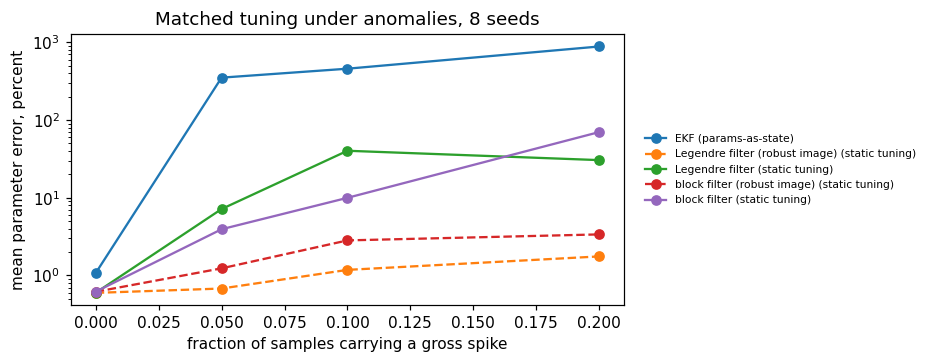

In [17]:
fig, ax = plt.subplots(figsize=(8.6, 3.4))
shown = [c for c in piv.columns
         if "static tuning" in c or c == "EKF (params-as-state)"]
for col in shown:
    ax.plot(piv.index, piv[col], marker="o",
            linestyle="--" if "robust" in col else "-", label=col)
ax.set_yscale("log")
ax.set_xlabel("fraction of samples carrying a gross spike")
ax.set_ylabel("mean parameter error, percent")
ax.set_title(f"Matched tuning under anomalies, {SEEDS} seeds")
ax.legend(fontsize=7, loc="center left", bbox_to_anchor=(1.02, 0.5),
          frameon=False)
fig.tight_layout()
plt.show()

In [18]:
dropout_sweep.pivot(index="level", columns="estimator", values="perr_pct")

estimator,EKF (params-as-state),Legendre filter (inherited tuning),Legendre filter (robust image) (inherited tuning),Legendre filter (robust image) (static tuning),Legendre filter (static tuning),block filter (inherited tuning),block filter (robust image) (inherited tuning),block filter (robust image) (static tuning),block filter (static tuning)
level,,,,,,,,,
0.05,1.128272,7.482857,7.648529,0.599624,0.595844,6.866844,5.419774,0.616464,0.613999
0.10,1.011528,7.701821,7.838608,0.538114,0.534737,5.915730,5.958344,0.660036,0.665618
0.20,1.076775,11.638414,12.354815,0.658272,0.653366,12.286210,12.903770,0.631901,0.629385


In [19]:
piv_d = dropout_sweep.pivot(index="level", columns="estimator", values="perr_pct")
# fails if any value is not finite (a filter diverging over a gap would
# show as inf or nan here)
assert np.isfinite(piv_d.to_numpy()).all()
static_cols = [c for c in piv_d.columns if "static tuning" in c]
clean = noise_sweep.pivot(index="noise", columns="estimator",
                          values="perr_pct").loc[0.05]
for col in static_cols:
    # fails if a matched-tuning filter more than doubles its full-grid
    # error under a dropout of up to 20 percent
    assert (piv_d[col] < 2.0 * clean[col.replace(" (robust image)", "")]).all(), col
    # fails if a matched-tuning filter falls behind the EKF under dropout
    assert (piv_d[col] < piv_d["EKF (params-as-state)"]).all(), col
print(piv_d)

estimator  EKF (params-as-state)  Legendre filter (inherited tuning)  \
level                                                                  
0.05                    1.128272                            7.482857   
0.10                    1.011528                            7.701821   
0.20                    1.076775                           11.638414   

estimator  Legendre filter (robust image) (inherited tuning)  \
level                                                          
0.05                                                7.648529   
0.10                                                7.838608   
0.20                                               12.354815   

estimator  Legendre filter (robust image) (static tuning)  \
level                                                       
0.05                                             0.599624   
0.10                                             0.538114   
0.20                                             0.658272   

estimator  L

Robustness is the reweighting, not the basis and not the tuning.
At 10 percent anomalies every robust-image row is under 3 percent mean
parameter error (1.18 to 2.83) while the plain row of the same basis in
the same tuning runs from 9.996 to 67.6, and the EKF, which has no outlier
handling at all, is at 459 percent: a spike moves its random-walk state
directly. The reweighting costs nothing where there is nothing to
reweight: on the clean row the robust and the plain image read 0.617
against 0.618 percent in the matched tuning and 9.99 against 9.88 in the
inherited one. Nothing about spreading a spike over `1/W` of a window is
doing the work, since the robust and the plain filter image the same
window and differ only in the weights.

Dropout is not a missed time update for any of these estimators, and for
the matched tuning it is not a loss either: those rows hold 0.53 to 0.67
percent mean error from 5 through 20 percent dropout, which is where they
sit on a full grid (0.60 and 0.62 percent), and a little ahead of the
EKF's 1.01 to 1.13. The row that degrades is the inherited one, from 5.4
to 7.6 percent at 5 percent dropout to 11.6 to 12.9 at 20 percent. An
adaptive window that shrinks on thin data, driven by a process noise that
keeps moving the parameters between measurements, is what suffers from a
gap; the window image as such does not.


In [20]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("21_filter_form", "anomaly_sweep", anomaly_sweep)
    notebook.save_table("21_filter_form", "dropout_sweep", dropout_sweep)
    print("wrote experiments/results/21_filter_form/{anomaly,dropout}_sweep.csv")

wrote experiments/results/21_filter_form/{anomaly,dropout}_sweep.csv


## 6. A jump in a parameter: the alarm and the return to the new value

The same sinusoid model, amplitude jumping from 2.0 to 3.5 (`w=1.5`
unchanged), tracked by a Legendre-order-5 filter with an adaptive and with
a fixed window, both `window_size=60`, over a 70 s record.

`ImageFilter` consults its own detector once per window of full-window
updates, so where the jump lands inside that stride decides how long the
detector waits for its next look. The jump time is therefore swept over
one stride, from 30.0 s to 35.5 s in 0.5 s steps, at every seed: a single
jump time measures the phase it happens to hit, not the detector.

Four arrangements of the alarm, each under both window rules:

- the filter's own detector, polled once per window;
- a chi-square test of `nis_` on every sample, which is a `FilterBank` of
  one filter under its `FusedChiSquareDetector` (threshold at
  `alpha=1e-4` for the image's six coefficients, warm-up three windows,
  cool-down one window), the filter's own detector switched off and the
  flag multiplying `P` by four through `inflate`;
- the same per-sample test re-arming the filter through `rearm()` under
  `drift_reset="inflate"`: `P` inflated and the adaptive window collapsed
  to `min_window`, the newest samples kept;
- the same under `drift_reset="full"`: `P` reset and the window cleared,
  so no sample from before the jump stays in it.

Latency is from the jump to the first flag after it. A false alarm is a
flag between the third window and the jump; the runs of one seed share
their stream up to the jump, so false alarms are counted in seeds as well
as in runs. Settling is the time from the jump until the amplitude
estimate stays within 5 percent of 3.5 for two seconds.

In [21]:
JUMPS = np.arange(30.0, 36.0, 0.5)[::4 if QUICK else 1]
drift_t = np.arange(0.0, 70.0, SIN_DT)
SETTLE_BAND, SETTLE_HOLD = 0.05, 2.0
OWN = "own detector, once per window"
PER_SAMPLE = "per-sample test, inflate"
REARM_KEEP = "per-sample test, rearm (inflate reset)"
REARM_FULL = "per-sample test, rearm (full reset)"
ALARMS = [(OWN, dict(per_sample=False)),
          (PER_SAMPLE, dict(per_sample=True)),
          (REARM_KEEP, dict(per_sample=True, rearm=True)),
          (REARM_FULL, dict(per_sample=True, rearm=True, reset="full"))]


def settling_time(amp, j, target=3.5):
    inside = np.abs(amp - target) < SETTLE_BAND * target
    hold = int(round(SETTLE_HOLD / SIN_DT))
    for i in range(j, amp.size - hold):
        if inside[i:i + hold].all():
            return (i - j) * SIN_DT
    return np.nan


def drift_run(adaptive, jump, seed, *, per_sample, rearm=False,
              reset="inflate"):
    rng = np.random.default_rng(seed)
    y = np.where(drift_t < jump, 2.0, 3.5) * np.sin(1.5 * drift_t)
    y = y + 0.1 * rng.standard_normal(drift_t.size)
    own_off = dict(alpha=1e-15, cusum_k=np.inf) if per_sample else {}
    bank = FilterBank.from_model("A*sin(w*t)", "t", 1, basis="legendre",
                                 order=5, window_size=SIN_W, p0=[2.0, 1.5],
                                 adaptive_window=adaptive, drift_reset=reset,
                                 **own_off)
    flt = bank.filters[0]
    det = (bank.fused_detector(alpha=1e-4, inflate=4.0, rearm=rearm)
           if per_sample else None)
    amp = np.empty(drift_t.size)
    flags = []
    for i in range(drift_t.size):
        sample = np.array([y[i]])
        if per_sample:
            flagged = det.update(float(drift_t[i]), sample)
        else:
            bank.partial_fit(float(drift_t[i]), sample)
            flagged = bool(flt.drift_flag_)
        if flagged:
            flags.append(i)
        amp[i] = flt.params_["A"]
    j = int(np.searchsorted(drift_t, jump))
    after = [i for i in flags if i >= j]
    early = [i for i in flags if 3 * SIN_W <= i < j]
    latency = (after[0] - j) * SIN_DT if after else np.nan
    return latency, len(early), len(after), settling_time(amp, j)


runs = []
for alarm, kw in ALARMS:
    for adaptive in (True, False):
        for jump in JUMPS:
            for s in range(SEEDS):
                latency, early, late, settle = drift_run(
                    adaptive, float(jump), s, **kw)
                runs.append(dict(alarm=alarm,
                                 window="adaptive" if adaptive else "fixed",
                                 jump_s=float(jump), seed=s,
                                 latency_s=latency, false_alarms=early,
                                 flags_after=late,
                                 settling_s=settle))
drift_runs = pd.DataFrame(runs)

rows = []
for (alarm, window), g in drift_runs.groupby(["alarm", "window"], sort=False):
    rows.append(dict(
        alarm=alarm, window=window, runs=len(g),
        detected=int(g.latency_s.notna().sum()),
        latency_mean_s=float(g.latency_s.mean()),
        latency_median_s=float(g.latency_s.median()),
        latency_max_s=float(g.latency_s.max()),
        false_alarm_runs=int((g.false_alarms > 0).sum()),
        false_alarm_seeds=int(g[g.false_alarms > 0].seed.nunique()),
        flags_after_max=int(g.flags_after.max()),
        settling_mean_s=float(g.settling_s.mean()),
        settling_median_s=float(g.settling_s.median()),
        settling_max_s=float(g.settling_s.max()),
        unsettled=int(g.settling_s.isna().sum())))
drift_response = pd.DataFrame(rows)

drift_phase = (drift_runs.groupby(["alarm", "window", "jump_s"], sort=False)
               .agg(latency_mean_s=("latency_s", "mean"),
                    detected=("latency_s", lambda v: int(v.notna().sum())),
                    seeds=("seed", "size"))
               .reset_index())
drift_response

,alarm,window,runs,detected,latency_mean_s,latency_median_s,latency_max_s,false_alarm_runs,false_alarm_seeds,flags_after_max,settling_mean_s,settling_median_s,settling_max_s,unsettled
0,"own detector, once per window",adaptive,96,53,1.352830,1.0,3.2,0,0,1,2.360417,2.8,3.5,0
1,"own detector, once per window",fixed,96,76,3.267105,3.3,5.8,12,1,1,5.257292,5.3,5.6,0
2,"per-sample test, inflate",adaptive,96,96,0.077083,0.0,0.4,0,0,1,2.367708,2.8,3.5,0
3,"per-sample test, inflate",fixed,96,96,0.077083,0.0,0.4,0,0,1,5.257292,5.3,5.6,0
4,"per-sample test, rearm (inflate reset)",adaptive,96,96,0.077083,0.0,0.4,0,0,1,1.198958,1.5,2.0,0
5,"per-sample test, rearm (inflate reset)",fixed,96,96,0.077083,0.0,0.4,0,0,1,5.257292,5.3,5.6,0
6,"per-sample test, rearm (full reset)",adaptive,96,96,0.077083,0.0,0.4,0,0,1,0.781250,0.7,1.1,0
7,"per-sample test, rearm (full reset)",fixed,96,96,0.077083,0.0,0.4,0,0,1,0.781250,0.7,1.1,0


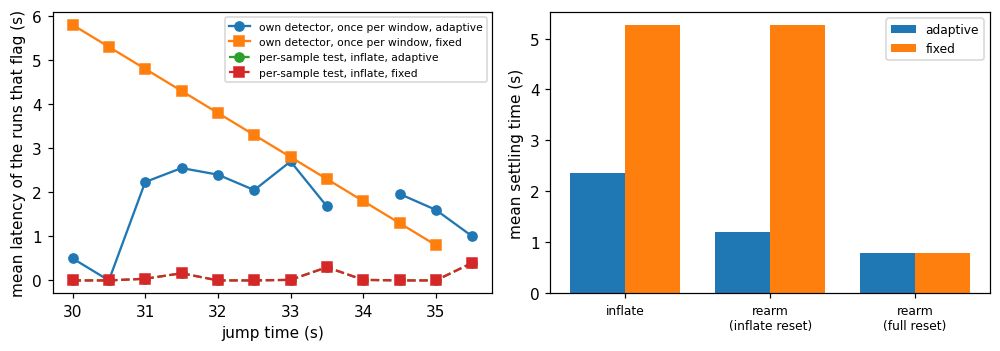

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.3))
for (alarm, window), g in drift_phase.groupby(["alarm", "window"], sort=False):
    if alarm not in (OWN, PER_SAMPLE):
        continue
    axes[0].plot(g.jump_s, g.latency_mean_s,
                 marker="o" if window == "adaptive" else "s",
                 ls="-" if alarm == OWN else "--",
                 label=f"{alarm}, {window}")
axes[0].set_xlabel("jump time (s)")
axes[0].set_ylabel("mean latency of the runs that flag (s)")
axes[0].legend(fontsize=7)
shown = drift_response[drift_response.alarm != OWN]
x = np.arange(shown.alarm.nunique())
for k, window in enumerate(("adaptive", "fixed")):
    part = shown[shown.window == window]
    axes[1].bar(x + (k - 0.5) * 0.38, part.settling_mean_s, 0.38, label=window)
axes[1].set_xticks(x)
axes[1].set_xticklabels(["inflate", "rearm\n(inflate reset)",
                         "rearm\n(full reset)"], fontsize=8)
axes[1].set_ylabel("mean settling time (s)")
axes[1].legend(fontsize=8)
fig.tight_layout()

In [23]:
resp = drift_response.set_index(["alarm", "window"])
for window in ("adaptive", "fixed"):
    row = resp.loc[(PER_SAMPLE, window)]
    # fails if the per-sample test misses a jump at any phase or seed
    assert row.detected == row.runs, window
    # fails if the per-sample test needs more than ten samples at any phase
    assert row.latency_max_s <= 10 * SIN_DT, window
    # fails if it raises a false alarm in more than one seed in four
    assert row.false_alarm_seeds <= SEEDS / 4, window
    # fails if clearing the window on the flag does not shorten the
    # settling under this window rule
    assert (resp.loc[(REARM_FULL, window), "settling_mean_s"]
            < row.settling_mean_s), window
own_fixed = drift_phase[(drift_phase.alarm == OWN)
                        & (drift_phase.window == "fixed")].latency_mean_s
# fails if the own detector's latency under the fixed window does not span
# half a window stride across the jump phases, which is what a latency set
# by the detector rather than by where the jump lands would look like
assert own_fixed.max() - own_fixed.min() >= 0.5 * SIN_W * SIN_DT
# fails if the own detector catches every jump under the adaptive window,
# which would withdraw the reading that the shrinking window absorbs a
# jump before the next consult
assert resp.loc[(OWN, "adaptive"), "detected"] < resp.loc[(OWN, "adaptive"), "runs"]
# fails if the adaptive window does not settle clearly sooner than the
# fixed one under the same per-sample test with P alone re-armed
assert (resp.loc[(PER_SAMPLE, "adaptive"), "settling_mean_s"]
        <= 0.6 * resp.loc[(PER_SAMPLE, "fixed"), "settling_mean_s"])
print(drift_response[["alarm", "window", "detected", "runs", "latency_mean_s",
                      "latency_max_s", "false_alarm_seeds",
                      "settling_mean_s"]].to_string(index=False))

                                 alarm   window  detected  runs  latency_mean_s  latency_max_s  false_alarm_seeds  settling_mean_s
         own detector, once per window adaptive        53    96        1.352830            3.2                  0         2.360417
         own detector, once per window    fixed        76    96        3.267105            5.8                  1         5.257292
              per-sample test, inflate adaptive        96    96        0.077083            0.4                  0         2.367708
              per-sample test, inflate    fixed        96    96        0.077083            0.4                  0         5.257292
per-sample test, rearm (inflate reset) adaptive        96    96        0.077083            0.4                  0         1.198958
per-sample test, rearm (inflate reset)    fixed        96    96        0.077083            0.4                  0         5.257292
   per-sample test, rearm (full reset) adaptive        96    96        0.077083    

The filter's own detector reacts at its next consult, not at the jump.
Under the fixed window the consults fall 6 s apart and the latency is the
distance to the next one, to the sample: 5.8 s for a jump at 30.0 s, half
a second less for every half second the jump moves toward the consult,
0.8 s at 35.0 s, and no flag in any seed at 35.5 s, five samples before
the consult, where the window holds too little of the new amplitude to
cross the threshold and has re-converged by the consult after. Over the
twelve phases it flags 76 of 96 runs at a mean of 3.3 s. One seed of the
eight raises a false alarm before the jump, in all twelve of its runs
since they share the stream up to the jump, and after it that seed flags
no jump at any phase.

Under the adaptive window the own detector is consulted more often while
the window is short. It flags the two earliest phases in every seed within
half a second, the single phase an experiment with one jump time would
have measured; across the stride it flags 53 of 96 and raises no false
alarm. Its misses are jumps the window has already absorbed: the residual
autocorrelation shrinks the window, the process noise lets the amplitude
move, and by the next consult the innovation is back at its baseline.

The per-sample test flags all 96 jumps under either window rule, at the
jump sample itself in the median and four samples after it at worst, once
a run, with no false alarm. Its latency is the same under the two rules
because a grown adaptive window and a fixed one are the same filter until
the first flag.

What the window rule decides is how long the estimate takes to reach the
new amplitude. With `P` alone re-armed the adaptive window settles in
2.4 s in the mean and the fixed one in 5.3 s, the time the old amplitude
takes to leave a window of 6 s; the own-detector rows settle the same, so
it is the window rule and not the flag that does this. Inflating `P` does
not shorten either, because the samples from before the jump are still in
the window and the image still measures them. Collapsing the adaptive
window on the flag (`rearm()` under the inflate reset) halves its settling
to 1.2 s and does nothing for the fixed window, which has no length to
collapse. Clearing the window on the flag (the full reset) brings both to
0.8 s, 1.1 s at worst: the filter waits `min_window` samples and then
measures a window that holds the new amplitude only, and with that the
window rule no longer matters.

In [24]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("21_filter_form", "drift_response", drift_response)
    notebook.save_table("21_filter_form", "drift_phase", drift_phase)
    print("wrote experiments/results/21_filter_form/drift_response.csv "
          "and drift_phase.csv")

wrote experiments/results/21_filter_form/drift_response.csv and drift_phase.csv


## 7. Cost per step, and the multi-axis fault bank

Microseconds a step for the configurations of sections 1 to 6, timed as
the fastest of nine repeats over the same stream, the repeat least
interrupted by whatever else this shared machine was running, beside the
model's parameter count, the window and the basis image's coefficient
count. The spread column is the range over the nine repeats, so it is
this machine's load and not seed variation. Then the multi-axis
fault: a three-axis oscillator with a mid-run damping fault on every axis
at once, watched four ways. The fused chi-square detector
(`FusedChiSquareDetector` over a `FilterBank`) pools the three filters'
`nis_` and tests the sum on every sample. Three one-filter banks each test
their own `nis_` on every sample at `alpha=1e-4/3`, so that the three
together alarm falsely as often as the fused test. Three independent
filters keep their own detectors, polled once a window. A plain
constant-acceleration Kalman bank runs its own
normalized-innovation-squared test. The first two differ in pooling only,
the second and third in test rate only.

The fault is then shrunk (`make_multi`'s `fault`, the fraction of the
damping jump applied) over the seeds, where a gain from pooling should
show if it shows anywhere, and the fused flag's re-arms are scored by how
well the bank tracks the clean signal over the hundred samples after the
fault.

In [25]:
def repeat_min_cost(make, t, y, repeats=9):
    costs = []
    for _ in range(repeats):
        f = make()
        tic = time.perf_counter()
        for i in range(t.size):
            f.partial_fit(float(t[i]), float(y[i]))
        costs.append(1e6 * (time.perf_counter() - tic) / t.size)
    costs = np.array(costs)
    return float(costs.min()), float(costs.max() - costs.min())


plant = BY_KEY["damped_osc"]
rng = np.random.default_rng(0)
t_cost, y_cost, _ = gen_plant(plant, rng, noise=0.05)


def mk_cost(**kw):
    base = dict(model=plant["expr"], var="t", p0=list(plant["p0"]),
                window_size=plant["window"], q_diag=list(plant["q"]))
    base.update(kw)
    model, var = base.pop("model"), base.pop("var")
    return lambda: ImageFilter(model, var, **base)


cost_cases = [
    ("block order 3  W 60  fixed", mk_cost(basis="block", order=3,
                                            adaptive_window=False), 3, 60, 3),
    ("block order 3  W 60  adaptive", mk_cost(basis="block", order=3), 3, 60, 3),
    ("legendre order 5  W 60  fixed",
     mk_cost(basis="legendre", order=5, adaptive_window=False), 3, 60, 6),
    ("legendre order 5  W 60  adaptive",
     mk_cost(basis="legendre", order=5), 3, 60, 6),
    ("legendre order 9  W 200  fixed (retuned)",
     mk_cost(basis="legendre", order=9, window_size=200,
             q_diag=[1e-8] * 3, adaptive_window=False), 3, 200, 10),
]
rows = []
for label, make, n_params, window, n_coef in cost_cases:
    fastest, spread = repeat_min_cost(make, t_cost, y_cost)
    rows.append(dict(config=label, n_params=n_params, window=window,
                      n_coef=n_coef, us_per_step=fastest, spread_us=spread))

ekf_costs = []
for _ in range(9):
    f = EKFAd(plant)
    tic = time.perf_counter()
    for i in range(t_cost.size):
        f.step(float(t_cost[i]), float(y_cost[i]))
    ekf_costs.append(1e6 * (time.perf_counter() - tic) / t_cost.size)
ekf_costs = np.array(ekf_costs)
rows.append(dict(config="EKF (params-as-state)", n_params=3, window=None,
                  n_coef=None, us_per_step=float(ekf_costs.min()),
                  spread_us=float(ekf_costs.max() - ekf_costs.min())))
step_cost = pd.DataFrame(rows)
step_cost

,config,n_params,window,n_coef,us_per_step,spread_us
0,block order 3 W 60 fixed,3,60.0,3.0,100.206939,5.353394
1,block order 3 W 60 adaptive,3,60.0,3.0,104.307869,2.386946
2,legendre order 5 W 60 fixed,3,60.0,6.0,101.785537,5.807326
3,legendre order 5 W 60 adaptive,3,60.0,6.0,103.247356,4.723854
4,legendre order 9 W 200 fixed (retuned),3,200.0,10.0,122.990914,6.240550
5,EKF (params-as-state),3,NaN,NaN,12.344856,0.324586


In [26]:
# fails if any configuration costs 250 microseconds or more a step, the
# bound this machine is held to
assert (step_cost.us_per_step < 250.0).all()
by_cfg = step_cost.set_index("config").us_per_step
adaptive_over_fixed_leg = (by_cfg["legendre order 5  W 60  adaptive"]
                           / by_cfg["legendre order 5  W 60  fixed"])
adaptive_over_fixed_block = (by_cfg["block order 3  W 60  adaptive"]
                             / by_cfg["block order 3  W 60  fixed"])
# fails if the adaptive window's fastest repeat is more than 1.3 times
# the fixed window's at the same cap, the margin between a window sized
# from the data every step and one that is not
assert adaptive_over_fixed_leg <= 1.3
assert adaptive_over_fixed_block <= 1.3
print(f"legendre adaptive/fixed: {adaptive_over_fixed_leg:.2f}x  "
      f"block adaptive/fixed: {adaptive_over_fixed_block:.2f}x")


legendre adaptive/fixed: 1.01x  block adaptive/fixed: 1.04x


In [27]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("21_filter_form", "step_cost", step_cost)
    print("wrote experiments/results/21_filter_form/step_cost.csv")

wrote experiments/results/21_filter_form/step_cost.csv


In [28]:
rng = np.random.default_rng(0)
n_multi = 400 if QUICK else 900
t_multi, Y_multi, clean_multi, half = make_multi(rng, n=n_multi)

tr, pred_fused, rmse_fused, fp_fused, lat_fused, warm = run_tracker(
    t_multi, Y_multi, clean_multi, half, inflate=4.0)

indep = [ImageFilter(OSC, "t", basis="legendre", p0=[2.0, 2.5, 0.1], order=5,
                     window_size=60, q_diag=[1e-3] * 3)
         for _ in range(3)]
# Each filter's own drift detector is consulted once per full window, not
# once per sample, so the sample indices it is offered are recorded beside
# the flags: they bound when this arm can react at all.
consults = [[] for _ in range(3)]
sample = [0]


def counting_update(detector, log):
    inner = detector.update

    def update(innovation):
        log.append(sample[0])
        return inner(innovation)

    return update


for d in range(3):
    indep[d].detector.update = counting_update(indep[d].detector, consults[d])

flags_axis = np.zeros((t_multi.size, 3), dtype=bool)
for i in range(t_multi.size):
    sample[0] = i
    for d in range(3):
        indep[d].partial_fit(float(t_multi[i]), float(Y_multi[i, d]))
        flags_axis[i, d] = indep[d].drift_flag_
any_flag = flags_axis.any(axis=1)
fp_indep = int(any_flag[:half].sum())
after_indep = np.flatnonzero(any_flag[half:])
lat_indep = int(after_indep[0]) if after_indep.size else None
first_consult_after = min(
    min((i for i in log if i >= half), default=t_multi.size) for log in consults)

PER_AXIS = "three per-axis tests, every sample"
FUSED = "fused chi-square (bank)"


def fault_bank_of(k, **kw):
    return FilterBank.from_model(OSC, "t", k, basis="legendre",
                                 p0=[2.0, 2.5, 0.1], order=5, window_size=60,
                                 q_diag=[1e-3] * 3, cusum_h=np.inf, **kw)


def per_axis_flags(t, Y, alpha=1e-4 / 3):
    dets = [fault_bank_of(1).fused_detector(alpha=alpha, inflate=4.0)
            for _ in range(Y.shape[1])]
    for i in range(t.size):
        for d, det in enumerate(dets):
            det.update(float(t[i]), Y[i, d:d + 1])
    return sorted((i, d) for d, det in enumerate(dets) for i in det.flags_)


def first_flag(flags, half):
    flags = [f[0] if isinstance(f, tuple) else f for f in flags]
    after = [i for i in flags if i >= half]
    return (after[0] - half if after else None,
            len([i for i in flags if i < half]))


lat_axis, fp_axis = first_flag(per_axis_flags(t_multi, Y_multi), half)

kf = KalmanCA(dim=3, dt=float(np.mean(np.diff(t_multi))), q=1e-2, r=0.5)
threshold = chi2.ppf(1 - 1e-4, df=3)
kflags = np.zeros(t_multi.size, dtype=bool)
for i in range(Y_multi.shape[0]):
    kf.update(Y_multi[i])
    if i >= warm:
        kflags[i] = kf.last_nis_ > threshold
fp_kalman = int(kflags[:half].sum())
after_kalman = np.flatnonzero(kflags[half:])
lat_kalman = int(after_kalman[0]) if after_kalman.size else None

fault_bank = pd.DataFrame([
    dict(approach=FUSED, caught=lat_fused is not None,
         false_alarms=fp_fused, latency_steps=lat_fused),
    dict(approach=PER_AXIS, caught=lat_axis is not None,
         false_alarms=fp_axis, latency_steps=lat_axis),
    dict(approach="three independent filters", caught=lat_indep is not None,
         false_alarms=fp_indep, latency_steps=lat_indep),
    dict(approach="Kalman bank (own NIS test)", caught=lat_kalman is not None,
         false_alarms=fp_kalman, latency_steps=lat_kalman),
])
print(f"per-axis detector consults in {t_multi.size} samples: "
      f"{[len(log) for log in consults]}, of them before the fault at {half}: "
      f"{[sum(1 for i in log if i < half) for log in consults]}")
print(f"first consult after the fault {first_consult_after}, "
      f"per-axis flags {np.flatnonzero(any_flag).tolist()}")
fault_bank

per-axis detector consults in 900 samples: [14, 15, 16], of them before the fault at 450: [7, 7, 7]
first consult after the fault 469, per-axis flags [365, 469, 845]


,approach,caught,false_alarms,latency_steps
0,fused chi-square (bank),True,0,1.0
1,"three per-axis tests, every sample",True,0,1.0
2,three independent filters,True,1,19.0
3,Kalman bank (own NIS test),False,0,NaN


In [29]:
by_app = fault_bank.set_index("approach")
# fails if the fused test does not catch the fault with no false alarm
assert bool(by_app.loc["fused chi-square (bank)", "caught"])
assert by_app.loc["fused chi-square (bank)", "false_alarms"] == 0
lat_steps = by_app["latency_steps"].astype(float)
caught = by_app["caught"].astype(bool)
lat_fused_steps = float(lat_steps["fused chi-square (bank)"])
lat_indep_steps = float(lat_steps["three independent filters"])
for approach in ("three independent filters", "Kalman bank (own NIS test)"):
    other = float(lat_steps[approach])
    # fails if an approach reports a latency while its caught flag says it
    # never flagged the fault, or carries no latency while it did
    assert caught[approach] == np.isfinite(other), approach
    # fails if any of the other two approaches reacts sooner than the fused
    # test, the Kalman bank included
    assert not np.isfinite(other) or lat_fused_steps <= other, approach
# fails if per-axis tests on the fused test's own schedule trail it by more
# than two steps, which is what a gain from pooling would look like
lat_axis_steps = float(lat_steps[PER_AXIS])
assert np.isfinite(lat_axis_steps) and lat_axis_steps <= lat_fused_steps + 2
assert by_app.loc[PER_AXIS, "false_alarms"] == 0
# fails if a per-axis detector is consulted more often than once per window
# plus the warm-up, the schedule the reading holds the latency gap against
for log in consults:
    assert len(log) <= 2 + t_multi.size / 60
# fails if the per-axis arm raises before the first consult it is given
# after the fault, which would mean its latency is not its polling schedule
assert (not np.isfinite(lat_indep_steps)
        or half + lat_indep_steps >= first_consult_after)
print(fault_bank)

                             approach  caught  false_alarms  latency_steps
0             fused chi-square (bank)    True             0            1.0
1  three per-axis tests, every sample    True             0            1.0
2           three independent filters    True             1           19.0
3          Kalman bank (own NIS test)   False             0            NaN


In [30]:
FAULT_SIZES = [1.0, 0.25] if QUICK else [1.0, 0.5, 0.25, 0.1]
rows = []
leading_axis = {}
for size in FAULT_SIZES:
    got = {FUSED: [], PER_AXIS: []}
    leading_axis[size] = [0, 0, 0]
    for s in range(SEEDS):
        t_f, Y_f, _clean_f, half_f = make_multi(np.random.default_rng(s),
                                                n=n_multi, fault=size)
        fused = fault_bank_of(3).fused_detector(alpha=1e-4, inflate=4.0)
        for i in range(t_f.size):
            fused.update(float(t_f[i]), Y_f[i])
        got[FUSED].append(first_flag(fused.flags_, half_f))
        axis_flags = per_axis_flags(t_f, Y_f)
        got[PER_AXIS].append(first_flag(axis_flags, half_f))
        raised = [d for i, d in axis_flags if i >= half_f]
        if raised:
            leading_axis[size][raised[0]] += 1
    for approach, pairs in got.items():
        lat = np.array([np.nan if p[0] is None else p[0] for p in pairs])
        rows.append(dict(fault=size, approach=approach, seeds=SEEDS,
                         caught=int(np.isfinite(lat).sum()),
                         latency_mean_steps=float(np.nanmean(lat)),
                         latency_max_steps=float(np.nanmax(lat)),
                         false_alarms=int(sum(p[1] for p in pairs))))
fault_pooling = pd.DataFrame(rows)

REARMS = [("inflate P by 4", dict(inflate=4.0), "inflate"),
          ("rearm, inflate reset", dict(rearm=True), "inflate"),
          ("rearm, full reset", dict(rearm=True), "full")]
rows = []
for label, kw, reset in REARMS:
    scores = []
    for s in range(SEEDS):
        t_f, Y_f, clean_f, half_f = make_multi(np.random.default_rng(s),
                                               n=n_multi)
        bank = fault_bank_of(3, drift_reset=reset)
        det = bank.fused_detector(alpha=1e-4, **kw)
        pred = np.full(Y_f.shape, np.nan)
        for i in range(t_f.size):
            det.update(float(t_f[i]), Y_f[i])
            pred[i] = bank.predict(float(t_f[i]))
        seg = slice(half_f, half_f + 100)
        ok = np.all(np.isfinite(pred[seg]), axis=1)
        scores.append(float(np.sqrt(np.mean(
            (pred[seg][ok] - clean_f[seg][ok]) ** 2))))
    rows.append(dict(rearm=label, seeds=SEEDS,
                     rmse_after_fault_mean=float(np.mean(scores)),
                     rmse_after_fault_max=float(np.max(scores))))
fault_rearm = pd.DataFrame(rows)
print(f"seeds in which each axis raises first, by fault size: {leading_axis}")
print(fault_rearm.to_string(index=False))
fault_pooling

seeds in which each axis raises first, by fault size: {1.0: [0, 0, 8], 0.5: [0, 0, 8], 0.25: [0, 0, 8], 0.1: [0, 0, 8]}
               rearm  seeds  rmse_after_fault_mean  rmse_after_fault_max
      inflate P by 4      8               0.090553              0.094142
rearm, inflate reset      8               0.052989              0.063576
   rearm, full reset      8               0.076234              0.078662


,fault,approach,seeds,caught,latency_mean_steps,latency_max_steps,false_alarms
0,1.00,fused chi-square (bank),8,8,0.250,1.0,0
1,1.00,"three per-axis tests, every sample",8,8,0.125,1.0,0
2,0.50,fused chi-square (bank),8,8,0.500,1.0,0
3,0.50,"three per-axis tests, every sample",8,8,0.125,1.0,0
4,0.25,fused chi-square (bank),8,8,0.875,2.0,0
5,0.25,"three per-axis tests, every sample",8,8,0.750,2.0,0
6,0.10,fused chi-square (bank),8,8,3.125,7.0,0
7,0.10,"three per-axis tests, every sample",8,8,2.875,8.0,0


In [31]:
pool = fault_pooling.pivot(index="fault", columns="approach",
                           values="latency_mean_steps")
# fails if either arm misses the fault at any size or seed
assert (fault_pooling.caught == fault_pooling.seeds).all()
# fails if per-axis tests on the same schedule trail the fused test by more
# than two steps at any fault size, which is what a gain from pooling
# would look like
assert (pool[PER_AXIS] <= pool[FUSED] + 2).all()
by_rearm = fault_rearm.set_index("rearm").rmse_after_fault_mean
# fails if collapsing the windows on the flag does not track the clean
# signal better after the fault than inflating P alone
assert by_rearm["rearm, inflate reset"] < by_rearm["inflate P by 4"]
print(pool)

approach  fused chi-square (bank)  three per-axis tests, every sample
fault                                                                
0.10                        3.125                               2.875
0.25                        0.875                               0.750
0.50                        0.500                               0.125
1.00                        0.250                               0.125


Every configuration measured here costs about the same: the fastest of
nine repeats runs from 100 to 123 microseconds a step, against the 250 a
step this machine is held to. The range over the repeats on those five
rows is 2.4 to 6.2 microseconds, this machine being shared with other work
while the cell ran, which is why the table carries the fastest repeat and
not an average over them. The Legendre order 9 window of 200 is the
dearest of the five at 123 microseconds, and the EKF, with no window to
image at all, is eight to ten times cheaper at 12.3 microseconds a step.

The adaptive window comes out at 1.01 times the fixed one in the Legendre
configuration and 1.04 in the block one. Nine repeats put an adaptive
window within a tenth of a fixed one at this cap and no closer than that;
a figure to two digits would be reading this machine's load rather than
the filter. The state size and the embedded budget belong to notebook 24,
and the cost measured on a chip to the rig notebook.

On the multi-axis fault the two arms that test on every sample flag the
synchronized damping fault one step after it arrives and raise nothing
before it, pooled or not; the three independent filters with their own
polled detectors flag it 19 steps after and raise one false alarm at
sample 365; the plain constant-acceleration Kalman bank does not flag it
at all, its normalized innovation never crossing the threshold, since a
Kalman-CA position tracker follows the signal's shape however it changes
rather than testing it against a fixed model. That last one is the
comparison that does not depend on anything below: a test needs a model
that constrains the signal to have something to test against.

The test rate is the whole latency gap between the window-image arms.
`ImageFilter` consults its own detector once per full window rather than
once per sample (the counts printed above: 14 to 16 consults in 900
samples, seven of them before the fault on each axis). The first consult
any axis is given after the fault at sample 450 is 469, and 469 is exactly
where the polled arm raises; its false alarm is one of about seven
opportunities an axis. Run on every sample instead, at a threshold that
makes the three tests together alarm falsely as often as the fused one,
the per-axis tests are as fast as the fused test at every fault size over
the eight seeds: a mean of 0.1 to 2.9 steps against 0.25 to 3.1 as the
damping jump shrinks from the full one to a tenth of it, neither arm
missing a fault or raising a false alarm. Pooling the streams adds nothing
measurable here. The three axes do not carry the fault equally: the
third, the largest and fastest of them, raises first in every seed at
every size, so the per-axis arm is as fast as its strongest axis and the
sum has nothing to add to it.

After the flag, collapsing the windows (`rearm()` under the inflate reset)
tracks the clean signal over the next hundred samples at an RMSE of 0.053
against 0.091 for inflating `P` alone, and clearing them (the full reset)
at 0.076. Which re-arm is the better one depends on the change: the
amplitude jump of section 6 favours the cleared window, a damping change
on a continuous signal favours keeping the newest samples.

In [32]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("21_filter_form", "fault_bank", fault_bank)
    notebook.save_table("21_filter_form", "fault_pooling", fault_pooling)
    notebook.save_table("21_filter_form", "fault_rearm", fault_rearm)
    print("wrote experiments/results/21_filter_form/fault_bank.csv, "
          "fault_pooling.csv and fault_rearm.csv")

wrote experiments/results/21_filter_form/fault_bank.csv, fault_pooling.csv and fault_rearm.csv


## Findings and limits

The image filter's own convergence speed is set by `min_window`, not by
which basis measures it; the recursive equal-areas stage's own
observability step counts are notebook 17's and are not reproduced here.

The process noise decides the accuracy, not the basis. Matched to a plant
whose parameters do not move, the window filter leads the EKF on two of
the four plants, in the mean, in the median and in the majority of the
eight seeds, and is at parity on the other two: a sixth behind on the AC
sinusoid, and on the accelerating trajectory ahead in the mean only
because of a single EKF seed. It leads at every noise level on the damped
oscillator and under dropout. The tracking tuning the adapters inherit
loses to the EKF everywhere it is scored, by eight to nine times on the
damped oscillator.

A naive sliding-window refit is the worst estimator here that recovers
parameters at all. A model fitted to the wrong plant either leaves
float64 range (four of eight seeds on the decaying sinusoid read as a
rise) or scores several times worse in the median than the model that
generated the stream.

Robustness is the reweighting of the window, not the basis, not the
tuning and not the integration: the robust image is several times better
than its own plain row at a double-digit anomaly fraction and costs
nothing on clean data, while the EKF has no outlier handling and goes to
hundreds of percent.

A dropout is a thinner window, not a missed time update: the matched
tuning holds its full-grid accuracy through 20 percent of samples lost,
the inherited tuning does not.

A jump in a parameter is caught by a chi-square test of the window
innovation on every sample: all 96 jumps flagged within four samples,
no false alarm, under either window rule. The filter's own detector is
polled once per window, so its latency is where the jump lands in that
stride (0.8 to 5.8 s under the fixed window, a jump just before a consult
missed in every seed), and under the adaptive window it misses 43 of 96
jumps the window has already absorbed. What the adaptive window buys is
the return to the new value, 2.4 s against 5.3 s with `P` alone re-armed;
clearing the window on the flag brings either to 0.8 s.

On a fault that hits three streams at once the test rate is the whole gap
between one step and nineteen: per-axis tests run on every sample are as
fast as the pooled test at every fault size tried, and a Kalman bank
carrying no model of the signal does not flag it at all.

Limits: every plant here is synthetic, the noise is white and the outlier
model is a single spike shape; the matched tuning is the right setting
only where the parameters really are static, and nothing here measures
what it costs when they are not; the jump is one amplitude step at one
noise level, and the per-sample test's successive windows overlap, so
its `alpha` is a per-sample level and not a run length: no false alarm
over eight noise streams of 700 samples is all that is measured of it; the
multi-axis fault is one damping change on every axis at once with unequal
amplitudes, not a partial, asynchronous or evenly weak fault, which is
where pooling could still lead; every microsecond figure is this one
machine's, shared with whatever else was running on it at the time.

In [33]:
print(notebook.provenance(STARTED))

2026-09-21 commit c7f0be3 dtfit 0.4.0 dtfit-experimental 0.1.0 169.6s
